# EDA for loan default prediction

**Goal:** Predict whether a Home Credit **loan application** will **default** (`TARGET = 1`) or **not** (`TARGET = 0`) on the current contract.

**How we look for predictive features:** Risk-analysis queries live in `sql/eda/`. Each encodes a **hypothesis**; we group applicants into deciles or quartiles (or compare class means) and plot **default rate** or summary stats vs. `TARGET`. Per-applicant feature tables for modeling are built separately under `sql/features/` (not run here). Validate with proper splits and leakage checks before production training.

**Notebook pattern:** Each code cell **runs one SQL file from `sql/eda/`**, shows the **first 3 rows** of the result, then **plots** when the query is an aggregated risk view.

**Families covered:** application ratios, demographics, external scores, bureau depth, prior rejections, installments, credit-card utilization.


In [19]:
from __future__ import annotations

from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SQL_EDA = REPO_ROOT / "sql" / "eda"
DB_PATH = REPO_ROOT / "data" / "home_credit.db"

con = duckdb.connect(str(DB_PATH), read_only=True)

%matplotlib inline
plt.style.use("ggplot")


In [20]:
def run_sql_file(name: str) -> pd.DataFrame:
    path = SQL_EDA / name
    if not path.is_file():
        raise FileNotFoundError(path)
    return con.sql(path.read_text()).df()


def lower_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).lower() for c in out.columns]
    return out


def peek(df: pd.DataFrame, n: int = 3) -> None:
    display(df.head(n))


## Figures and data extracts

Each subsection runs **one** file from `sql/eda/`: **3-row preview**, then a chart when applicable.


### How imbalanced are the training labels?

**Question:** What share of training applications default?

**Answer:** There is an 8.1% default rate. 

,TARGET,n,pct
0,0,282686,91.927118
1,1,24825,8.072882


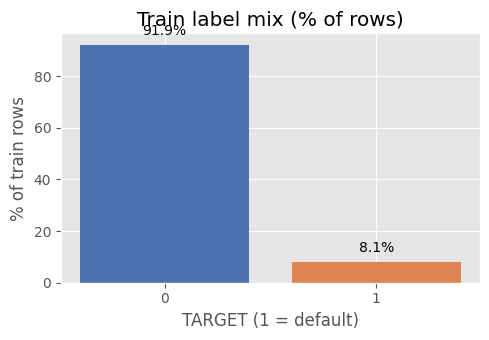

In [21]:
df = run_sql_file("target_distribution.sql")
peek(df)
td = lower_columns(df)
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(td["target"].astype(str), td["pct"], color=["#4c72b0", "#dd8452"])
ax.set_title("Train label mix (% of rows)")
ax.set_xlabel("TARGET (1 = default)")
ax.set_ylabel("% of train rows")

# Add bar labels
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.1f}%",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center", va="bottom", fontsize=10)

fig.tight_layout()

### Does requested credit size relate to default?

**Question:** Do applicants who ask for larger `AMT_CREDIT` buckets differ in default rate?

**How the data answers:** `amt_credit_risk.sql` bins `AMT_CREDIT` into deciles (1 = smallest loans). The line shows default rate % per decile. There is a higher default rate in the middle, between the 4th to 6th deciles.

,decile,n,n_default,default_rate_pct
0,1,30752,2029.0,6.597945
1,2,30751,2407.0,7.827388
2,3,30751,2506.0,8.149328


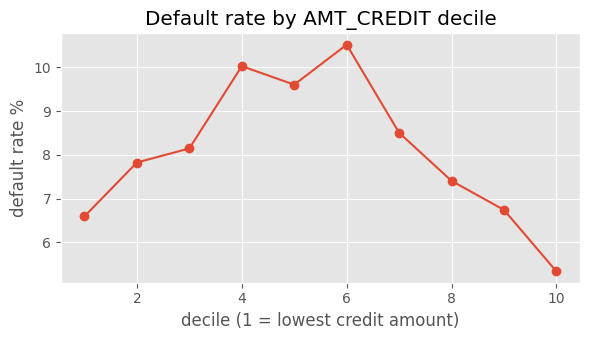

In [22]:
df = run_sql_file("amt_credit_risk.sql")
peek(df)
df = lower_columns(df)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(df["decile"], df["default_rate_pct"], marker="o")
ax.set_title("Default rate by AMT_CREDIT decile")
ax.set_xlabel("decile (1 = lowest credit amount)")
ax.set_ylabel("default rate %")
fig.tight_layout()

### Does declared income relate to default?

**Question:** Is default rate different across income deciles?

**How the data answers:** `amt_income_risk.sql` uses `ntile` on `AMT_INCOME_TOTAL`. The highest default rates are for the lower-middle deciles, with the lowest default rates for the highest deciles.

,bin,total_num,n_targets,default_rate
0,3,30751,2676.0,8.702156
1,6,30751,2662.0,8.656629
2,4,30751,2658.0,8.643621


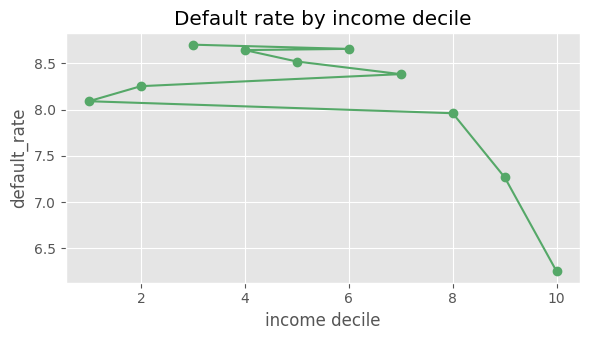

In [23]:
df = run_sql_file("amt_income_risk.sql")
peek(df)
df = lower_columns(df)
rate_col = "default_rate" if "default_rate" in df.columns else "default_rate_pct"
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(df["bin"], df[rate_col], marker="o", color="#55a868")
ax.set_title("Default rate by income decile")
ax.set_xlabel("income decile")
ax.set_ylabel(rate_col)
fig.tight_layout()

### Is payment burden (annuity / income) predictive?

**Question:** When monthly installment eats a larger fraction of income, is default more likely?

**How the data answers:** `annuity_to_income_risk.sql` deciles annuity / income. The higher the monthly installment relative to income, the higher the default rate. This is monotionically true, except for the highest 2 deciles.

,decile,n,n_default,default_rate_pct
0,1,30750,2168.0,7.050407
1,2,30750,2258.0,7.343089
2,3,30750,2404.0,7.817886


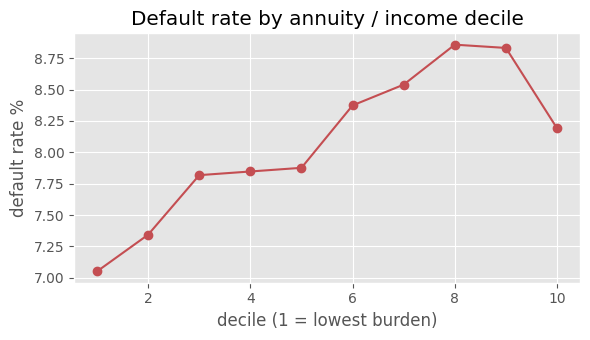

In [24]:
df = run_sql_file("annuity_to_income_risk.sql")
peek(df)
df = lower_columns(df)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(df["decile"], df["default_rate_pct"], marker="o", color="#c44e52")
ax.set_title("Default rate by annuity / income decile")
ax.set_xlabel("decile (1 = lowest burden)")
ax.set_ylabel("default rate %")
fig.tight_layout()

### Is leverage (credit / income) predictive?

**Question:** Does more credit relative to stated income correlate with default?

**How the data answers:** `credit_to_income_risk.sql` deciles credit-to-income. The default rate is low for the very high or very low deciles, showing that a moderate amount of credit has the highest default rate.

,decile,n,n_default,default_rate_pct
0,1,30752,2125.0,6.910120
1,2,30751,2385.0,7.755845
2,3,30751,2497.0,8.120061


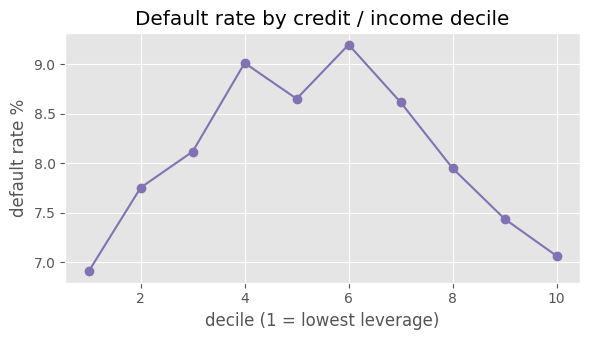

In [25]:
df = run_sql_file("credit_to_income_risk.sql")
peek(df)
df = lower_columns(df)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(df["decile"], df["default_rate_pct"], marker="o", color="#8172b3")
ax.set_title("Default rate by credit / income decile")
ax.set_xlabel("decile (1 = lowest leverage)")
ax.set_ylabel("default rate %")
fig.tight_layout()

### Does goods price vs. disbursed credit carry signal?

**Question:** When `AMT_GOODS_PRICE` is low relative to `AMT_CREDIT`, does risk change?

**How the data answers:** `goods_price_to_credit_risk.sql` deciles goods price / credit. The lower the ratio, the higher the default rate. This is surprising, because one would expect that goods mainly purchased on credit would have a lower default rate.

,decile,n,n_default,default_rate_pct
0,1,30724,3867.0,12.586252
1,2,30724,3335.0,10.854706
2,3,30724,2833.0,9.220805


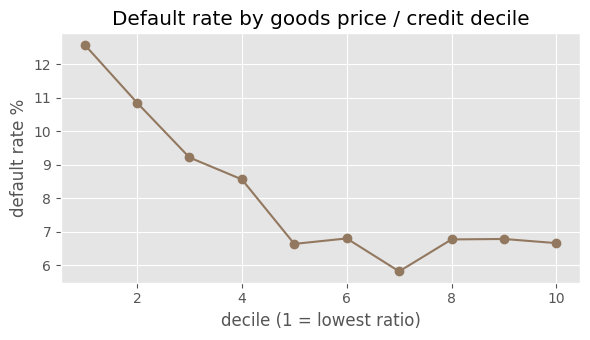

In [26]:
df = run_sql_file("goods_price_to_credit_risk.sql")
peek(df)
df = lower_columns(df)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(df["decile"], df["default_rate_pct"], marker="o", color="#937860")
ax.set_title("Default rate by goods price / credit decile")
ax.set_xlabel("decile (1 = lowest ratio)")
ax.set_ylabel("default rate %")
fig.tight_layout()

### How does age relate to default?

**Question:** Are younger or older applicants riskier after bucketing `DAYS_BIRTH`?

**How the data answers:** `age_risk.sql` uses age quartiles (1 = youngest). Younger applicants have a higher default rate.

,age_quartile,n,n_default,default_rate_pct
0,1,76878,8452.0,10.994043
1,2,76878,6656.0,8.657874
2,3,76878,5632.0,7.325893


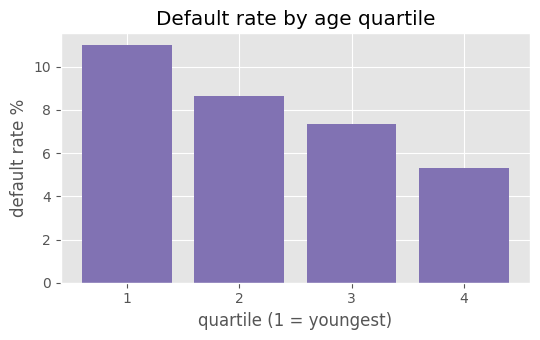

In [27]:
df = run_sql_file("age_risk.sql")
peek(df)
df = lower_columns(df)
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.bar(df["age_quartile"].astype(str), df["default_rate_pct"], color="#8172b3")
ax.set_title("Default rate by age quartile")
ax.set_xlabel("quartile (1 = youngest)")
ax.set_ylabel("default rate %")
fig.tight_layout()

### Which occupations show different default rates?

**Question:** After grouping `OCCUPATION_TYPE`, where is risk highest among common groups?

**How the data answers:** `occupational_risk.sql` aggregates by occupation. The chart uses the full aggregation (top 12 by volume). Drivers have the highest default rate and accountants the lowest.

,OCCUPATION_TYPE,total_num,n_targets,default_rate
0,Low-skill Laborers,2093,359.0,17.152413
1,Drivers,18603,2107.0,11.326130
2,Waiters/barmen staff,1348,152.0,11.275964


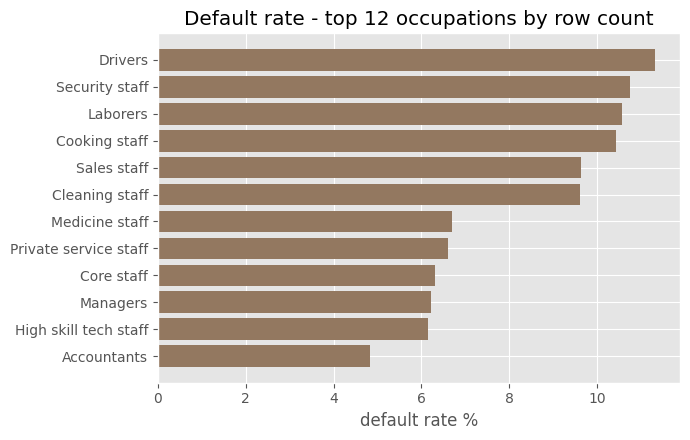

In [28]:
df = run_sql_file("occupational_risk.sql")
peek(df)
# Get top 12 by row count, then sort by default rate descending for plotting
occ = (
    lower_columns(df)
    .dropna(subset=["occupation_type"])
    .sort_values("total_num", ascending=False)
    .head(12)
    .sort_values("default_rate", ascending=False)
)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(occ["occupation_type"].astype(str), occ["default_rate"], color="#937860")
ax.invert_yaxis()
ax.set_title("Default rate - top 12 occupations by row count")
ax.set_xlabel("default rate %")
fig.tight_layout()

### Do external bureau scores separate defaulters?

**Question:** Are mean `EXT_SOURCE_*` values different for `TARGET` 0 vs 1?

**How the data answers:** `external_scores_by_target.sql` averages each score by class. External sources show a clear trend in predicting higher values for safe applicats, and lower values for defaulters.

,TARGET,avg_ext_source_1,avg_ext_source_2,avg_ext_source_3
0,0,0.511461,0.523479,0.520969
1,1,0.386968,0.410935,0.390717


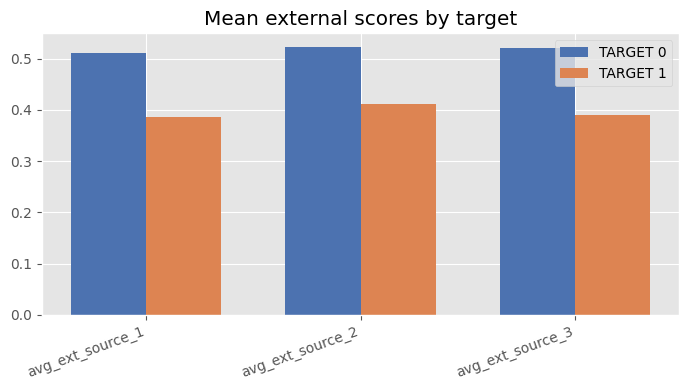

In [29]:
df = run_sql_file("external_scores_by_target.sql")
peek(df)
ext = lower_columns(df)
metrics = sorted([c for c in ext.columns if c.startswith("avg_ext")])
x = range(len(metrics))
w = 0.35
t0 = ext.loc[ext["target"] == 0, metrics].iloc[0].values
t1 = ext.loc[ext["target"] == 1, metrics].iloc[0].values
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - w / 2 for i in x], t0, width=w, label="TARGET 0", color="#4c72b0")
ax.bar([i + w / 2 for i in x], t1, width=w, label="TARGET 1", color="#dd8452")
ax.set_xticks(list(x))
ax.set_xticklabels(metrics, rotation=20, ha="right")
ax.set_title("Mean external scores by target")
ax.legend()
fig.tight_layout()

### Is credit-file depth (number of bureau lines) informative?

**Question:** Do applicants with more bureau trade lines default at different rates?

**How the data answers:** `bureau_depth_risk.sql` deciles count of `bureau` rows per applicant (zeros included). Very little history or a large amount of history both have a higher default rate. A moderate amount of history has the lowest default rate.

,decile,n,n_default,default_rate_pct
0,1,30752,3123.0,10.155437
1,2,30751,2847.0,9.258236
2,3,30751,2502.0,8.136321


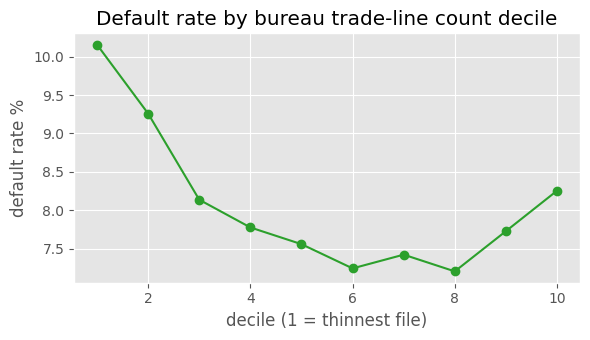

In [30]:
df = run_sql_file("bureau_depth_risk.sql")
peek(df)
df = lower_columns(df)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(df["decile"], df["default_rate_pct"], marker="o", color="#2ca02c")
ax.set_title("Default rate by bureau trade-line count decile")
ax.set_xlabel("decile (1 = thinnest file)")
ax.set_ylabel("default rate %")
fig.tight_layout()

### Does past rejection friction predict future default?

**Question:** Does a higher share of previous applications with `CODE_REJECT_REASON` track higher default?

**How the data answers:** `prev_rejection_share_risk.sql` deciles rejections / previous apps.

,decile,n,n_default,default_rate_pct
0,1,29106,2438.0,8.376280
1,2,29106,2315.0,7.953687
2,3,29106,2390.0,8.211365


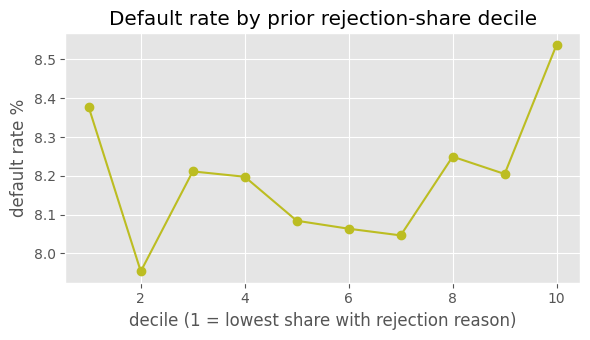

In [31]:
df = run_sql_file("prev_rejection_share_risk.sql")
peek(df)
df = lower_columns(df)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(df["decile"], df["default_rate_pct"], marker="o", color="#bcbd22")
ax.set_title("Default rate by prior rejection-share decile")
ax.set_xlabel("decile (1 = lowest share with rejection reason)")
ax.set_ylabel("default rate %")
fig.tight_layout()

### Are late installment payments associated with default?

**Question:** Is the fraction of installment rows paid after the due date higher for future defaulters?

**How the data answers:** `installments_target_summary.sql` compares % late rows by `TARGET`.

,TARGET,n_payment_rows,n_late_rows,pct_late_rows
0,0,10709348,896710.0,8.373152
1,1,879661,96919.0,11.017767


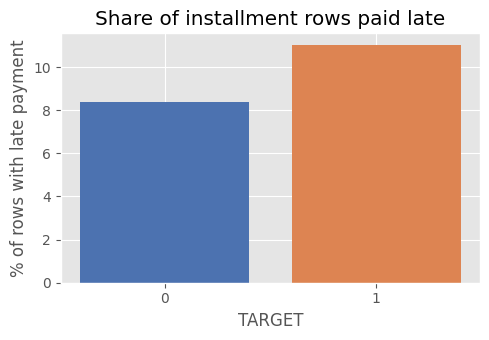

In [32]:
df = run_sql_file("installments_target_summary.sql")
peek(df)
inst = lower_columns(df)
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(inst["target"].astype(str), inst["pct_late_rows"], color=["#4c72b0", "#dd8452"])
ax.set_title("Share of installment rows paid late")
ax.set_xlabel("TARGET")
ax.set_ylabel("% of rows with late payment")
fig.tight_layout()

### Does revolving utilization predict default?

**Question:** Does higher mean balance/limit on credit cards align with higher default rates?

**How the data answers:** `credit_card_util_risk.sql` deciles mean utilization from `credit_card_balance`. The higher the credite-card utilization, the higher the default rate. This is specifically true for the upper half of the deciles.

,decile,n,n_default,default_rate_pct
0,1,8604,473.0,5.497443
1,2,8604,437.0,5.079033
2,3,8604,487.0,5.660158


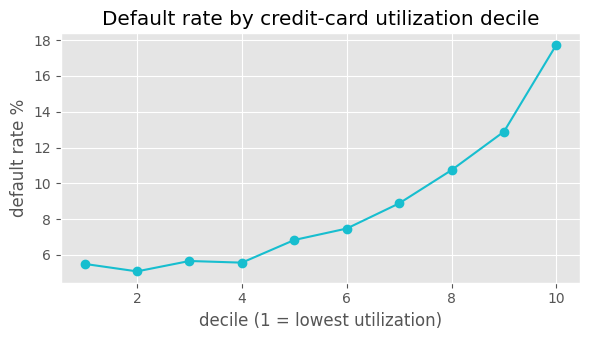

In [33]:
df = run_sql_file("credit_card_util_risk.sql")
peek(df)
df = lower_columns(df)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(df["decile"], df["default_rate_pct"], marker="o", color="#17becf")
ax.set_title("Default rate by credit-card utilization decile")
ax.set_xlabel("decile (1 = lowest utilization)")
ax.set_ylabel("default rate %")
fig.tight_layout()